IMPORTS

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from xgboost import XGBRegressor

CARGAR DATASET

In [18]:
df = pd.read_csv("CCH_dataset.csv")

FECHA A DATETIME

In [19]:
df["datalectura"] = pd.to_datetime(df["datalectura"])

SELECCIONAR CT

In [20]:
ct_estudio = "CT-0710"

df = df[df["ct"] == ct_estudio].copy()

ORDENADO POR FECHA

In [21]:
df = df.sort_values("datalectura")

VARIABLES TEMPORALES

In [22]:
df["hora"] = df["datalectura"].dt.hour

df["dia_semana"] = df["datalectura"].dt.dayofweek

df["mes"] = df["datalectura"].dt.month

df["fin_semana"] = (
    df["dia_semana"]
    .isin([5,6])
    .astype(int)
)

CREAR VARIABLES LAG

In [23]:
#Úlitma hora del dataset
df["lag_1"] = (
    df["ENERGIA_ENTRANTE"]
    .shift(1)
)

In [24]:
#Una dia antes de la última hora del dataset (24 registros antes)

df["lag_24"] = (
    df["ENERGIA_ENTRANTE"]
    .shift(24)
)

In [25]:
#Una semana antes de la última hora del dataset (168 registros antes)
df["lag_168"] = (
    df["ENERGIA_ENTRANTE"]
    .shift(168)
)

ELIMINAR NULOS

In [26]:
df = df.dropna()

DEFINIR VARIABLES PREDICTORAS

In [27]:
features = [
    "hora",
    "dia_semana",
    "mes",
    "fin_semana",
    "lag_1",
    "lag_24",
    "lag_168"
]

X = df[features]

y = df["ENERGIA_ENTRANTE"]

SPLIT TEMPORAL

In [28]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

BASELINE NAIVE

In [29]:
y_pred_naive = X_test["lag_24"]

mae_naive = mean_absolute_error(
    y_test,
    y_pred_naive
)

rmse_naive = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_naive
    )
)

mape_naive = np.mean(
    np.abs(
        (y_test - y_pred_naive) / y_test
    )
) * 100

print("Baseline naive")
print("MAE:", mae_naive)
print("RMSE:", rmse_naive)
print("MAPE:", mape_naive)

Baseline naive
MAE: 28.224950552646888
RMSE: 40.38064454232109
MAPE: 15.828706057806057


MODELO XGBOOST

XGBoost
MAE: 19.656995603906477
RMSE: 26.314468986363593
MAPE: 11.860344659686627


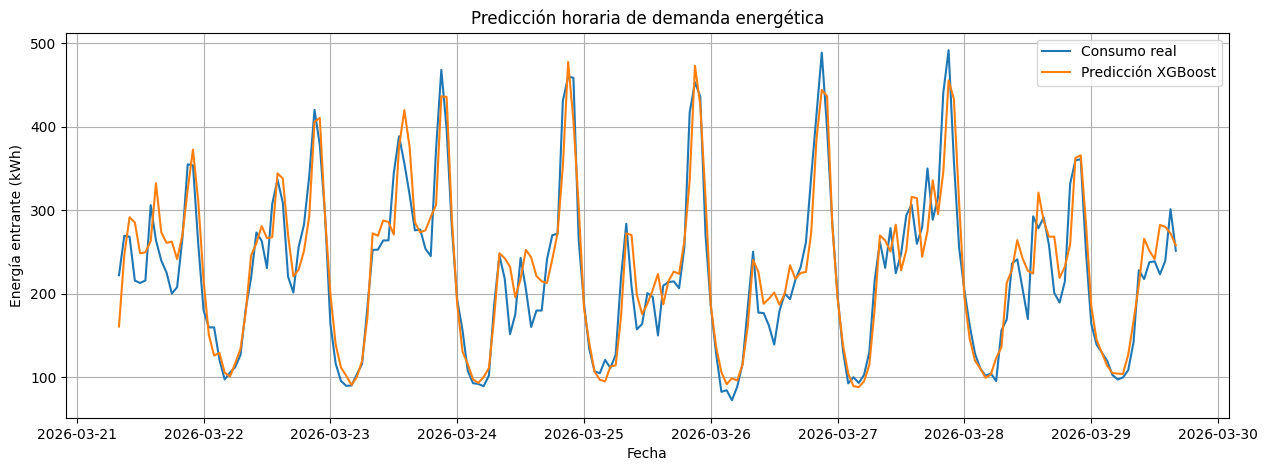

In [30]:
model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

#entrenar modelo
model.fit(X_train, y_train)

#Predicción
y_pred_xgb = model.predict(X_test)

#Métricas
mae_xgb = mean_absolute_error(
    y_test,
    y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)

mape_xgb = np.mean(
    np.abs(
        (y_test - y_pred_xgb) / y_test
    )
) * 100

print("XGBoost")

print("MAE:", mae_xgb)

print("RMSE:", rmse_xgb)

print("MAPE:", mape_xgb)

#Visualización
plt.figure(figsize=(15,5))

plt.plot(
    df.iloc[split:]["datalectura"][:200],
    y_test.values[:200],
    label="Consumo real"
)

plt.plot(
    df.iloc[split:]["datalectura"][:200],
    y_pred_xgb[:200],
    label="Predicción XGBoost"
)

plt.title("Predicción horaria de demanda energética")

plt.xlabel("Fecha")

plt.ylabel("Energía entrante (kWh)")

plt.legend()

plt.grid(True)

plt.show()

COMPARACIÓN DE MÉTRICAS

In [31]:
resultados = pd.DataFrame({

    "Modelo": [
        "Naive",
        "XGBoost"
    ],

    "MAE": [
        mae_naive,
        mae_xgb
    ],

    "RMSE": [
        rmse_naive,
        rmse_xgb
    ],

    "MAPE": [
        mape_naive,
        mape_xgb
    ]
})

resultados

,Modelo,MAE,RMSE,MAPE
0,Naive,28.224951,40.380645,15.828706
1,XGBoost,19.656996,26.314469,11.860345


Guardar resultados


In [32]:
resultados_xgb = pd.DataFrame({
    "fecha": df.iloc[split:]["datalectura"].values,
    "ct": df.iloc[split:]["ct"].values,
    "real": y_test.values,
    "prediccion": y_pred_xgb
})

resultados_xgb.to_csv(
    "predicciones_xgb.csv",
    index=False
)